# 05 — Fraud Detection & Anomaly Analysis

*Unsupervised fraud detection: 16 engineered behavioural features → composite risk scores → 232 flagged customers*

## Executive Summary

No fraud labels exist in this dataset. This notebook builds a detection system from scratch — engineering behavioural signals, running unsupervised anomaly detection, and producing a risk-ranked customer list that gives analysts somewhere actionable to start.

**7,903 customers · 34,500 transactions · 16 engineered features → 232 flagged (2.9%) · $96,822 estimated exposure**

| Output | Size | Contents |
|---|---|---|
| `fraud_risk_profile.parquet` | 7,903 × 26 | Full feature matrix + scores + tiers for downstream use |
| `fraud_risk_summary.csv` | 232 rows | High/Critical customers for analyst review |

---

> **Before acting on these results, note:**
> - Scores reflect *elevated risk*, not confirmed fraud — all detection is unsupervised
> - The 5% contamination assumption drives anomaly model sensitivity; it is not an empirical fraud rate
> - If we had real fraud labels, we could set the contamination to match the actual fraud rate, or choose a threshold based on precision and recall.
> - Rule thresholds are calibrated starting points — validate with domain experts before operationalising
> - Blend weights (Rule 40% · IF 30% · LOF 30%) and all thresholds live in `config.yaml`

## 1. Environment Setup

`random_state = 42` seeded globally. Structured logging scoped to run ID. All thresholds, weights, and model parameters externalised to `config.yaml` — nothing hardcoded downstream.

In [1]:
# Standard imports
import sys
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical
from scipy import stats

# ML
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Setup project path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

# Custom utilities
from n5a_utils import (
    get_project_root, load_config, setup_logger, get_output_paths,
    print_section_header, set_run_id, generate_run_id,
    verify_project_structure, validate_config,
)

# Redirect all handlers to stdout for consistent notebook output
for _name in list(logging.Logger.manager.loggerDict.keys()) + ['root']:
    _lgr = logging.getLogger(_name) if _name != 'root' else logging.getLogger()
    for _h in _lgr.handlers:
        if isinstance(_h, logging.StreamHandler):
            _h.stream = sys.stdout

# Initialise run
run_id = set_run_id()
logger = setup_logger(__name__)

# Load configuration
config = load_config()
paths  = get_output_paths(config)

# Global constants
RANDOM_STATE = config.get('notebook5', {}).get('random_state', 42)
np.random.seed(RANDOM_STATE)

# Validate notebook5 config keys exist
validate_config(config)

# Visualisation style
warnings.filterwarnings('ignore')
plt.style.use(config['visualization']['style'])
sns.set_palette(config['visualization']['color_palette'])

# Display settings
nb5_cfg = config.get('notebook5', {})
disp    = nb5_cfg.get('display', {})
pd.set_option('display.max_columns',  disp.get('max_columns', None))
pd.set_option('display.max_rows',     disp.get('max_rows', 100))
pd.set_option('display.float_format', disp.get('float_format', '{:.4f}').format)

# Verify project structure
verify_project_structure(project_root)

print(f"Pipeline Run ID:   {run_id}")
print(f"Project root:      {project_root}")
print(f"Output directory:  {paths['figures']}")

Pipeline Run ID:   B11970F1
Project root:      c:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project
Output directory:  c:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures\notebook5_fig


## 2. Data Ingestion & Integrity Check

Loads `enhanced_df.parquet` and `rfm_df.parquet` from NB01 with hash verification. Before a single feature is computed, six data contract checks run: customer ID overlap, nulls in critical fields, `returned` flag integrity, discount bounds [0, 1], positive `total_amount`, and no duplicate RFM customer IDs.

**Pipeline halts on any failure** — downstream scores are only as trustworthy as the inputs.

In [2]:
from n5b_data_loader import load_transaction_data, load_rfm_data, validate_data_integrity

# Load datasets
df_tx  = load_transaction_data(config, run_id=run_id, verbose=True)
rfm_df = load_rfm_data(config, run_id=run_id, verbose=True)

# Cross-dataset integrity validation
integrity_results = validate_data_integrity(df_tx, rfm_df, config, run_id=run_id)

print(f"\n{'='*80}")
print("DATA INTEGRITY VALIDATION".center(80))
print("=" * 80)

for check in integrity_results['checks']:
    symbol = 'PASS' if check['status'] == 'PASS' else ('WARN' if check['status'] == 'WARN' else 'FAIL')
    print(f"  [{symbol}] {check['name']:<45} {check['detail']}")

print()
print(f"  Passed: {integrity_results['passed']} | "
      f"Warnings: {integrity_results['warnings']} | "
      f"Failed: {integrity_results['failed']}")

if not integrity_results['all_passed']:
    raise ValueError("Data integrity validation failed — review issues above before proceeding")

print(f"\nDATA GATE: PASSED — proceeding to feature engineering")
print("=" * 80)


                            TRANSACTION DATA LOADED                             

Source:             enhanced_df.parquet
Rows:               34,500
Columns:            17
Date range:         2023-09-12 -> 2025-09-11
Unique customers:   7,903
Unique products:    24,912
Return rate:        5.52%
Negative margins:   6,104 (17.7%)

                                RFM DATA LOADED                                 

Source:             rfm_df.parquet
Customers:          7,903
Features:           17
Avg recency (days): 165.3
Avg frequency:      4.14
Median monetary:    $450.97
Avg loyalty score:  0.385

                           DATA INTEGRITY VALIDATION                            
  [PASS] Customer ID overlap                           100.0% of transaction customers present in RFM
  [PASS] Null values in critical columns               0 nulls found in ['total_amount', 'discount', 'returned', 'profit_margin']
  [PASS] Binary returned column                        Unique values: {np.int8(0), 

## 3. Feature Engineering

Builds a **38-feature behavioural matrix** at the customer level — 16 selected as model inputs (`config.yaml`). Features span six fraud dimensions:

| Dimension | What it captures |
|---|---|
| **Return behaviour** | Return rate; returns concentrated at high discounts |
| **Discount exploitation** | Max discount rate; always-at-max-discount flag; overall usage |
| **Velocity** | Max orders per 7-day / 30-day window; burst flag; inter-order gap variability |
| **Order value** | P95/P99 high-value order rates; order value spread; AOV z-score |
| **Margin** | Negative margin rate; average and minimum profit margin |
| **Diversity** | Category concentration (HHI); payment method count and concentration |

Velocity features use per-customer rolling windows — runtime scales linearly with customer count.

In [3]:
from n5c_feature_engineering import engineer_fraud_features, get_feature_list

print_section_header("FRAUD FEATURE ENGINEERING")

fraud_features = engineer_fraud_features(
    df=df_tx,
    rfm=rfm_df,
    config=config,
    run_id=run_id,
    verbose=True,
)

# Feature list to pass to models
model_features = get_feature_list(config)
available_model_features = [f for f in model_features if f in fraud_features.columns]

print(f"\nModel input features: {len(available_model_features)}")
for i, feat in enumerate(available_model_features, 1):
    print(f"  {i:2d}. {feat}")


                           FRAUD FEATURE ENGINEERING                            


                              FRAUD FEATURE MATRIX                              

Customers:          7,903
Features:           38

Feature                                   Mean     Median        Std
----------------------------------------------------------------------
return_rate                             0.0549     0.0000     0.1242
discount_usage_rate                     0.4525     0.5000     0.2779
max_discount_rate                       0.0205     0.0000     0.0802
negative_margin_rate                    0.1762     0.1429     0.2101
max_orders_7d                           1.1668     1.0000     0.3819
velocity_burst_flag                     0.0034     0.0000     0.0584
high_value_rate_p95                     0.0496     0.0000     0.1224
category_hhi                            0.4104     0.3333     0.2126
order_value_cv                          1.0251     1.0369     0.4897
always_max_discount    

### 3.1 Feature Distributions

All six summary features are **right-skewed** (skew: 1.38–6.05). That's expected — in a mostly clean customer base, fraud signals should be rare and extreme.

Three features — `return_rate`, `max_discount_rate`, `high_value_rate_p95` — have a **median of zero**. Most customers show no signal at all; the risk lives in a long tail. The remaining three (`negative_margin_rate`, `max_orders_7d`, `category_hhi`) have non-zero medians, reflecting behaviour that exists across the base regardless of fraud risk.

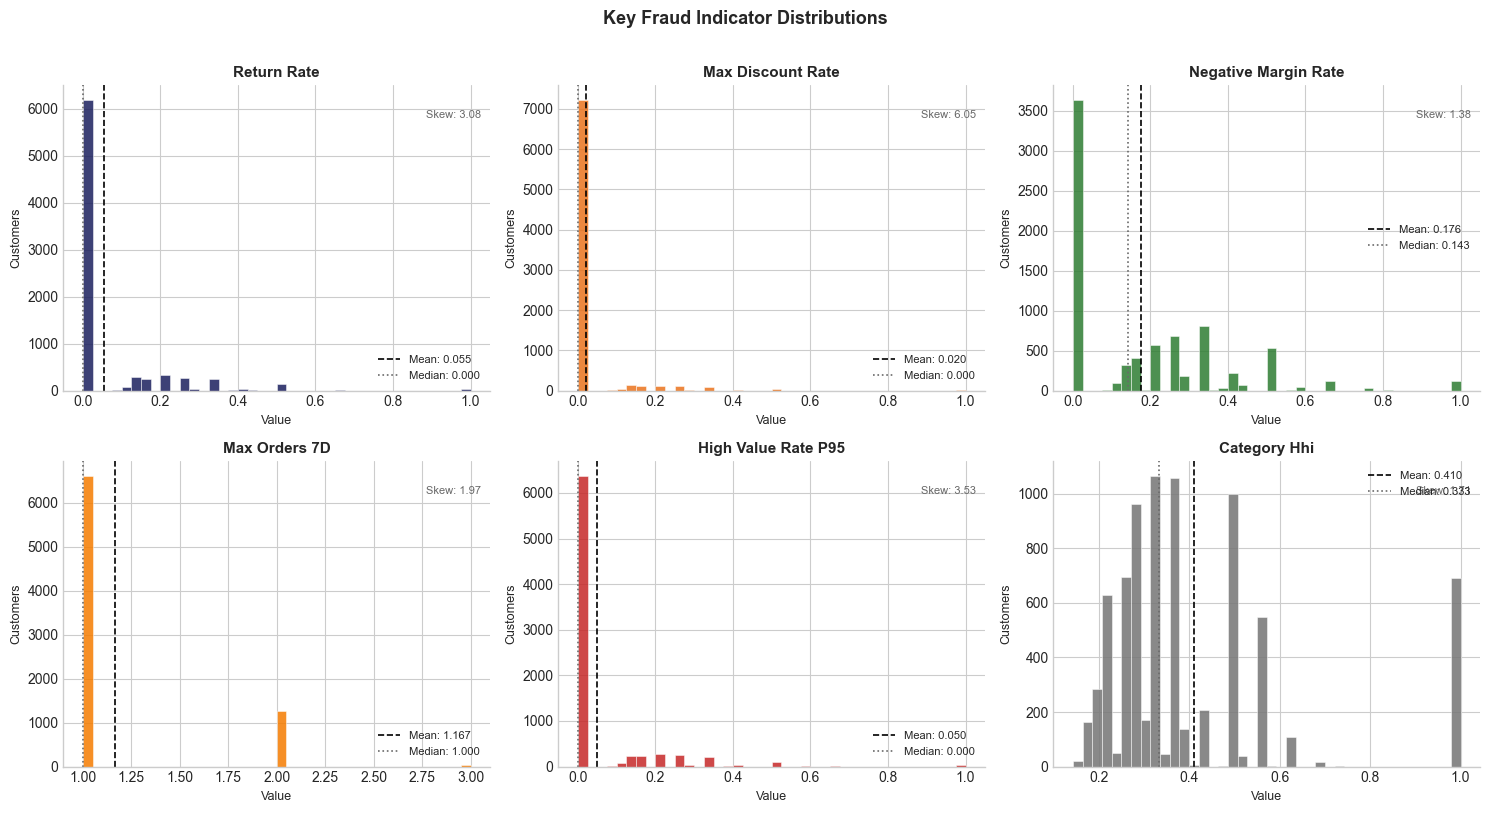


Figure saved: feature_distributions_B11970F1.png

                          FEATURE DISTRIBUTION SUMMARY                          

Feature                                 Mean   Median      Std     Skew      p95
------------------------------------------------------------------------------
return_rate                           0.0549   0.0000   0.1242     3.08   0.3333
max_discount_rate                     0.0205   0.0000   0.0802     6.05   0.1667
negative_margin_rate                  0.1762   0.1429   0.2101     1.38   0.5000
max_orders_7d                         1.1668   1.0000   0.3819     1.97   2.0000
high_value_rate_p95                   0.0496   0.0000   0.1224     3.53   0.3333
category_hhi                          0.4104   0.3333   0.2126     1.71   1.0000


In [4]:
# Distribution plots for key fraud features
key_features = [
    'return_rate', 'max_discount_rate', 'negative_margin_rate',
    'max_orders_7d', 'high_value_rate_p95', 'category_hhi',
]
key_features = [f for f in key_features if f in fraud_features.columns]

colors = config['visualization']['color_palette']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    ax = axes[idx]
    s  = fraud_features[feat].dropna()

    ax.hist(s, bins=40, color=colors[idx % len(colors)], alpha=0.85,
            edgecolor='white', linewidth=0.4)
    ax.axvline(s.mean(),   color='black',  linestyle='--', linewidth=1.2,
               label=f'Mean: {s.mean():.3f}')
    ax.axvline(s.median(), color='dimgray', linestyle=':',  linewidth=1.2,
               label=f'Median: {s.median():.3f}')

    skew = s.skew()
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Customers', fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.98, 0.92, f'Skew: {skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='dimgray')
    ax.spines[['top', 'right']].set_visible(False)

for idx in range(len(key_features), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Key Fraud Indicator Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

fig_path = paths['figures'] / f'feature_distributions_{run_id}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"\nFigure saved: {fig_path.name}")

# Statistical summary
print(f"\n{'='*80}")
print("FEATURE DISTRIBUTION SUMMARY".center(80))
print("=" * 80)
print(f"\n{'Feature':<35} {'Mean':>8} {'Median':>8} {'Std':>8} {'Skew':>8} {'p95':>8}")
print("-" * 78)
for feat in key_features:
    s = fraud_features[feat].dropna()
    print(
        f"{feat:<35} {s.mean():>8.4f} {s.median():>8.4f} "
        f"{s.std():>8.4f} {s.skew():>8.2f} {s.quantile(0.95):>8.4f}"
    )
print("=" * 80)

## 4. Rule-Based Risk Scoring

Seven behavioural rules each produce a normalised contribution [0, 1], weighted and summed into a composite score. Scores are then **normalised to the population maximum**, so the highest-risk customer always anchors at 1.0 and all others express relative severity.

This makes scores comparable across runs but means they are *population-relative*, not absolute — a score of 0.80 means "in the top tier of this cohort", not "80% likely to be fraudulent".

In [5]:
from n5d_scoring import compute_rule_based_scores, get_rule_descriptions

print_section_header("RULE-BASED FRAUD SCORING")

fraud_scored = compute_rule_based_scores(
    fraud_features=fraud_features,
    config=config,
    run_id=run_id,
    verbose=True,
)

logger.info("Rule-based scoring complete: %d customers scored", len(fraud_scored))


                            RULE-BASED FRAUD SCORING                            


                            RULE-BASED FRAUD SCORING                            

Customers scored:   7,903
Mean fraud score:   0.1999
Median:             0.1724
90th percentile:    0.4202
95th percentile:    0.5293

Rule                             Weight    Mean Contrib  Max Contrib
----------------------------------------------------------------------
return_abuse                       0.20          0.0390       0.2000
discount_exploitation              0.15          0.0038       0.1500
high_discount_returns              0.20          0.0070       0.2000
velocity_anomaly                   0.15          0.0125       0.1500
margin_exploitation                0.15          0.0492       0.1500
order_value_anomaly                0.10          0.0037       0.1000
category_concentration             0.05          0.0223       0.0500

Score Distribution:
----------------------------------------
  [0.0–0.2): 4

### 4.1 Rule Contributions

Two distinct patterns emerge from mean vs. maximum contributions:

**Widespread but moderate signals** — Margin Exploitation leads by mean (0.0492), roughly 1.3× Return Abuse (0.0390). Category Concentration ranks third (0.0223) despite carrying the lowest rule weight (0.05). These three signals are prevalent across the customer base — they reflect common behavioural variation, not rare fraud-specific spikes.

**Rare but maximal signals** — Return Abuse and High Discount Returns both reach their maximum contribution (0.2000) while maintaining low means. These are the high-severity outliers driving Critical-tier assignment.

**The top-10 list confirms it:** every highest-scoring customer simultaneously maxes both return signals. The return + high-discount-return co-occurrence is the dominant Critical-tier signature.

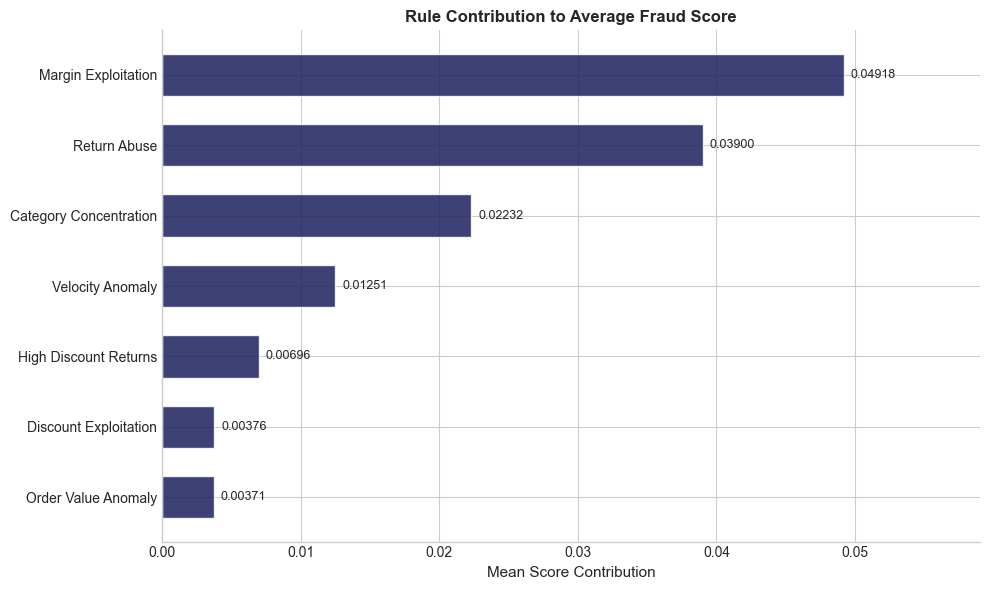


                      TOP 10 HIGHEST RULE-SCORE CUSTOMERS                       
customer_id  rule_fraud_score_norm  score_return_abuse  score_discount_exploitation  score_high_discount_returns  score_velocity_anomaly
     C10541                 1.0000              0.2000                       0.0000                       0.2000                  0.0750
     C16813                 0.9801              0.2000                       0.0000                       0.2000                  0.0750
     C17294                 0.8997              0.2000                       0.0000                       0.2000                  0.0000
     C14464                 0.8985              0.2000                       0.0469                       0.2000                  0.0750
     C13377                 0.8946              0.2000                       0.0000                       0.2000                  0.0750
     C16184                 0.8817              0.2000                       0.0000             

In [6]:
# Identify score component columns
score_component_cols = [c for c in fraud_scored.columns if c.startswith('score_')]
rule_names = [c.replace('score_', '') for c in score_component_cols]

# Bar chart: Mean contribution per rule
mean_contributions = fraud_scored[score_component_cols].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    [r.replace('_', ' ').title() for r in mean_contributions.index.str.replace('score_', '')],
    mean_contributions.values,
    color=config['visualization']['colors']['primary'],
    alpha=0.85,
    edgecolor='white',
    height=0.6,
)

for bar, val in zip(bars, mean_contributions.values):
    ax.text(
        bar.get_width() + mean_contributions.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.5f}', va='center', ha='left', fontsize=9,
    )

ax.set_xlabel('Mean Score Contribution', fontsize=11)
ax.set_title('Rule Contribution to Average Fraud Score', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, mean_contributions.max() * 1.2)
plt.tight_layout()

fig_path = paths['figures'] / f'rule_contributions_{run_id}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

# Top 10 highest rule-score customers
print(f"\n{'='*80}")
print("TOP 10 HIGHEST RULE-SCORE CUSTOMERS".center(80))
print("=" * 80)

top_rule = fraud_scored.nlargest(10, 'rule_fraud_score_norm')[
    ['customer_id', 'rule_fraud_score_norm'] + score_component_cols[:4]
]
print(top_rule.to_string(index=False, float_format='{:.4f}'.format))
print("=" * 80)

## 5. Anomaly Detection

Two unsupervised models applied to the scaled feature matrix — chosen because they detect anomalies from different perspectives:

| Model | How it works | Mean score |
|---|---|---|
| **Isolation Forest** | Anomalies need fewer random splits to isolate — *global* outliers | 0.2109 |
| **Local Outlier Factor** | Anomalies are sparse relative to their local peer group — *local* outliers | 0.0039 |

The **54× score divergence** is expected — they operate on fundamentally different scales. Both are normalised to [0, 1] individually before blending. The contamination parameter (5%) is a modelling assumption sourced from `config.yaml`, not a measured fraud rate.

In [7]:
from n5e_anomaly_detection import run_anomaly_detection, compare_model_agreement

print_section_header("UNSUPERVISED ANOMALY DETECTION")

anomaly_results = run_anomaly_detection(
    fraud_features=fraud_scored,
    feature_cols=available_model_features,
    config=config,
    run_id=run_id,
    verbose=True,
)

df_anomaly = anomaly_results['df']
metadata   = anomaly_results['metadata']

logger.info("Anomaly detection complete")


                         UNSUPERVISED ANOMALY DETECTION                         


                           ANOMALY DETECTION RESULTS                            

Customers analysed:      7,903
Features used:           16

Model                           Anomalies       Rate    Avg Score
-----------------------------------------------------------------
Isolation Forest                      395       5.0%       0.2109
Local Outlier Factor                  396       5.0%       0.0039
Both Models (ensemble)                 82       1.0%       0.1074
19:23:45 | INFO     | __main__ | Anomaly detection complete


### 5.1 Model Agreement

The two models flag largely different customers — and that's by design.

| Flagged by | Count |
|---|---|
| Both models | 82 |
| Isolation Forest only | 313 |
| LOF only | 314 |

**Cohen's Kappa = 0.1656** (slight agreement). Isolation Forest finds global outliers; LOF finds customers anomalous within their local peer group. They are complementary, not redundant — disagreement is informative.

Despite binary flag divergence, scores align directionally (Spearman ρ = 0.412, p < 0.001), and high rule-score customers cluster toward high IF scores — confirming partial convergence on the same high-risk population across both systems.


                            MODEL AGREEMENT ANALYSIS                            

Agreement Table:
lof_anomaly_flag  LOF: Anomaly  LOF: Normal   All
iso_anomaly_flag                                 
IF: Anomaly                 82          313   395
IF: Normal                 314         7194  7508
All                        396         7507  7903

Both flag as anomaly:   82 customers
Either flags as anomaly: 709 customers
Agreement rate:          92.1%
Cohen's Kappa:           0.1656
Interpretation:          Slight agreement — models detect different anomaly types


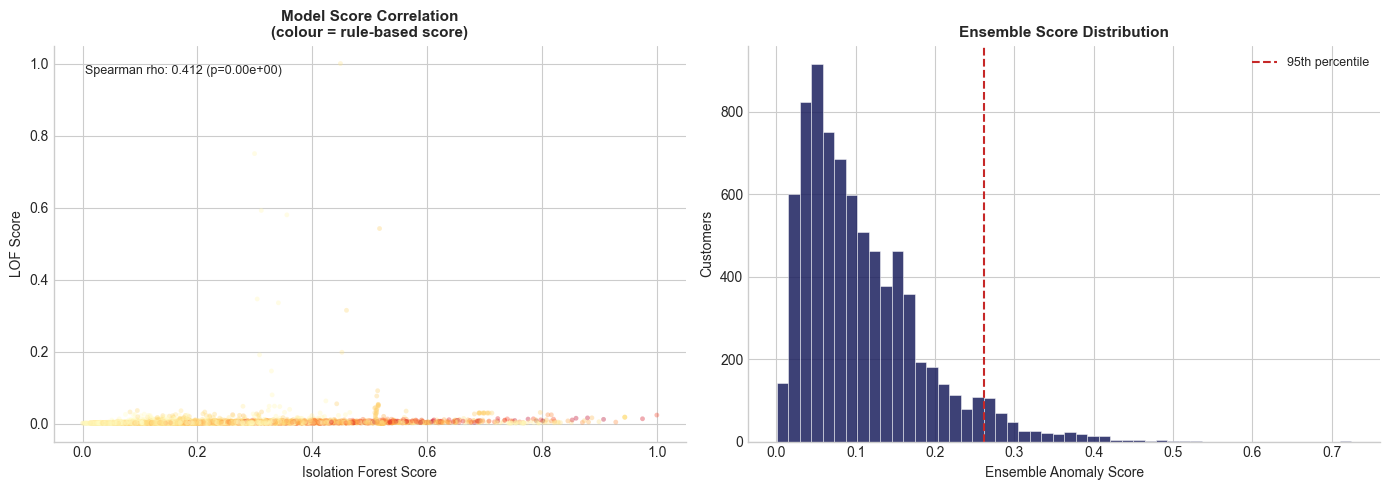


Figure saved: model_agreement_B11970F1.png


In [8]:
from n5e_anomaly_detection import compare_model_agreement

agreement_table = compare_model_agreement(df_anomaly, verbose=True)

# Visualise score correlation between models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score correlation
ax = axes[0]
ax.scatter(
    df_anomaly['iso_anomaly_score'],
    df_anomaly['lof_anomaly_score'],
    alpha=0.35, s=12, linewidths=0,
    c=df_anomaly['rule_fraud_score_norm'],
    cmap='YlOrRd',
)
ax.set_xlabel('Isolation Forest Score', fontsize=10)
ax.set_ylabel('LOF Score', fontsize=10)
ax.set_title('Model Score Correlation\n(colour = rule-based score)', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Spearman correlation
rho, pval = stats.spearmanr(
    df_anomaly['iso_anomaly_score'],
    df_anomaly['lof_anomaly_score'],
)
ax.text(0.05, 0.95, f"Spearman rho: {rho:.3f} (p={pval:.2e})",
        transform=ax.transAxes, fontsize=9, va='top')

# Ensemble score distribution
ax = axes[1]
ax.hist(
    df_anomaly['ensemble_anomaly_score'], bins=50,
    color=config['visualization']['colors']['primary'],
    alpha=0.85, edgecolor='white', linewidth=0.4,
)
ax.axvline(
    df_anomaly['ensemble_anomaly_score'].quantile(0.95),
    color=config['visualization']['colors']['danger'],
    linestyle='--', linewidth=1.5, label='95th percentile',
)
ax.set_xlabel('Ensemble Anomaly Score', fontsize=10)
ax.set_ylabel('Customers', fontsize=10)
ax.set_title('Ensemble Score Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig_path = paths['figures'] / f'model_agreement_{run_id}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"\nFigure saved: {fig_path.name}")

## 6. Composite Scoring & Risk Tiers

Three scores blended into a single composite using weights from `config.yaml`:
**Rule 40% · Isolation Forest 30% · LOF 30%**

| Tier | Threshold | Customers | Share | Operational response |
|---|---|---|---|---|
| 🔴 Critical | ≥ 0.80 | 29 | 0.4% | Immediate account review |
| 🟠 High | ≥ 0.60 | 203 | 2.6% | Priority review queue |
| 🟡 Medium | ≥ 0.35 | 1,167 | 14.8% | Enhanced monitoring |
| 🟢 Low | < 0.35 | 6,504 | 82.3% | Normal operations |

**Two findings that cut against intuition:**

- Medium-tier customers have a higher average negative margin rate (0.2827) than High-tier (0.2278). Negative margins are distributed broadly and are common even at modest risk levels — margin exploitation alone does not breach the 0.60 threshold. It needs to co-occur with return or discount signals to push a composite score into High territory.
  
- Critical customers average fewer orders (3.76) than High (4.55) or Medium (4.50). Risk is driven by the nature of behaviour, not its frequency — a small number of high-return, high-discount transactions is more damaging than a large volume of routine ones.

In [9]:
from n5f_profiling import build_composite_risk_score, build_risk_profile_summary

df_risk = build_composite_risk_score(
    df=df_anomaly,
    config=config,
    run_id=run_id,
    verbose=True,
)

risk_profile_summary = build_risk_profile_summary(df_risk, verbose=True)


                             COMPOSITE RISK SCORING                             

Blend weights:
  Rule-based:        40%
  Isolation Forest:  30%
  LOF:               30%

Risk Tier       Customers    % Total   Mean Score
--------------------------------------------------
Critical               29       0.4%       0.8698
High                  203       2.6%       0.6752
Medium              1,167      14.8%       0.4384
Low                 6,504      82.3%       0.1708

                           RISK TIER PROFILE SUMMARY                            

           Customers % of Total  Avg Fraud Score  Avg Return Rate  Avg Max Disc. Rate  Avg Neg. Margin Rate  Avg Max Orders/7d  Avg Order Count  Avg Order Value
Risk Tier                                                                                                                                                       
Critical          29       0.4%           0.8698           0.4059              0.1164                0.2628             

### 6.1 Score & Tier Visualisations

**What the distributions show:**
The LOF score is near-zero for virtually the entire population (mean 0.004, median 0.002) while IF (mean 0.211, 0.174) and rule-based (mean 0.200, 0.172) operate on comparable scales. The composite sits at mean 0.226, median 0.194 — slightly above either input from additive blending.

**What the tier plots confirm:**
Critical-tier IQR is tight and high — the 0.80 threshold captures a genuinely distinct population, not borderline cases. Tier bands are well-separated with minimal overlap, supporting the current calibration.

**What the radar fingerprint reveals:**
Critical extends furthest on almost every axis — the highest-risk customers are multi-signal, not single-feature anomalies. Medium shows disproportionate Velocity Burst Flag; Low is elevated on Discount Usage Rate, reflecting normal population-wide behaviour.

**What the model agreement scatter flags:**
Critical and High customers cluster at high IF scores but near-zero LOF scores throughout. **LOF is contributing minimal tier separation** — its 30% blend weight may not be proportionate to its discriminatory contribution. One High-tier outlier at LOF ≈ 1.0 is anomalous on LOF alone and warrants manual review.

**What the top-50 heatmap confirms:**
`high_discount_return_rate` is the single dominant column — the densest and warmest across all 50 rows by a clear margin. `discount_usage_rate` and `order_value_cv` rank second and third — both are consistently warm orange across nearly every row, reflecting population-wide elevation rather than isolated spikes. `negative_margin_rate` sits fourth — broadly moderate orange across most rows. `category_hhi` is fifth — a mix of scattered reds and white cells. `return_rate` ranks sixth despite its high Spearman correlation — only ~5 deep red cells with most of the column light, meaning it is extreme in a small subset rather than broadly elevated. `max_orders_7d` is seventh — scattered orange with many white cells. `max_discount_rate` and `high_value_rate_p95` are mostly white/light throughout. `velocity_burst_flag` is the whitest column — a near-binary single spike with the rest near-zero. Note: the heatmap displays 10 of the 16 model features.

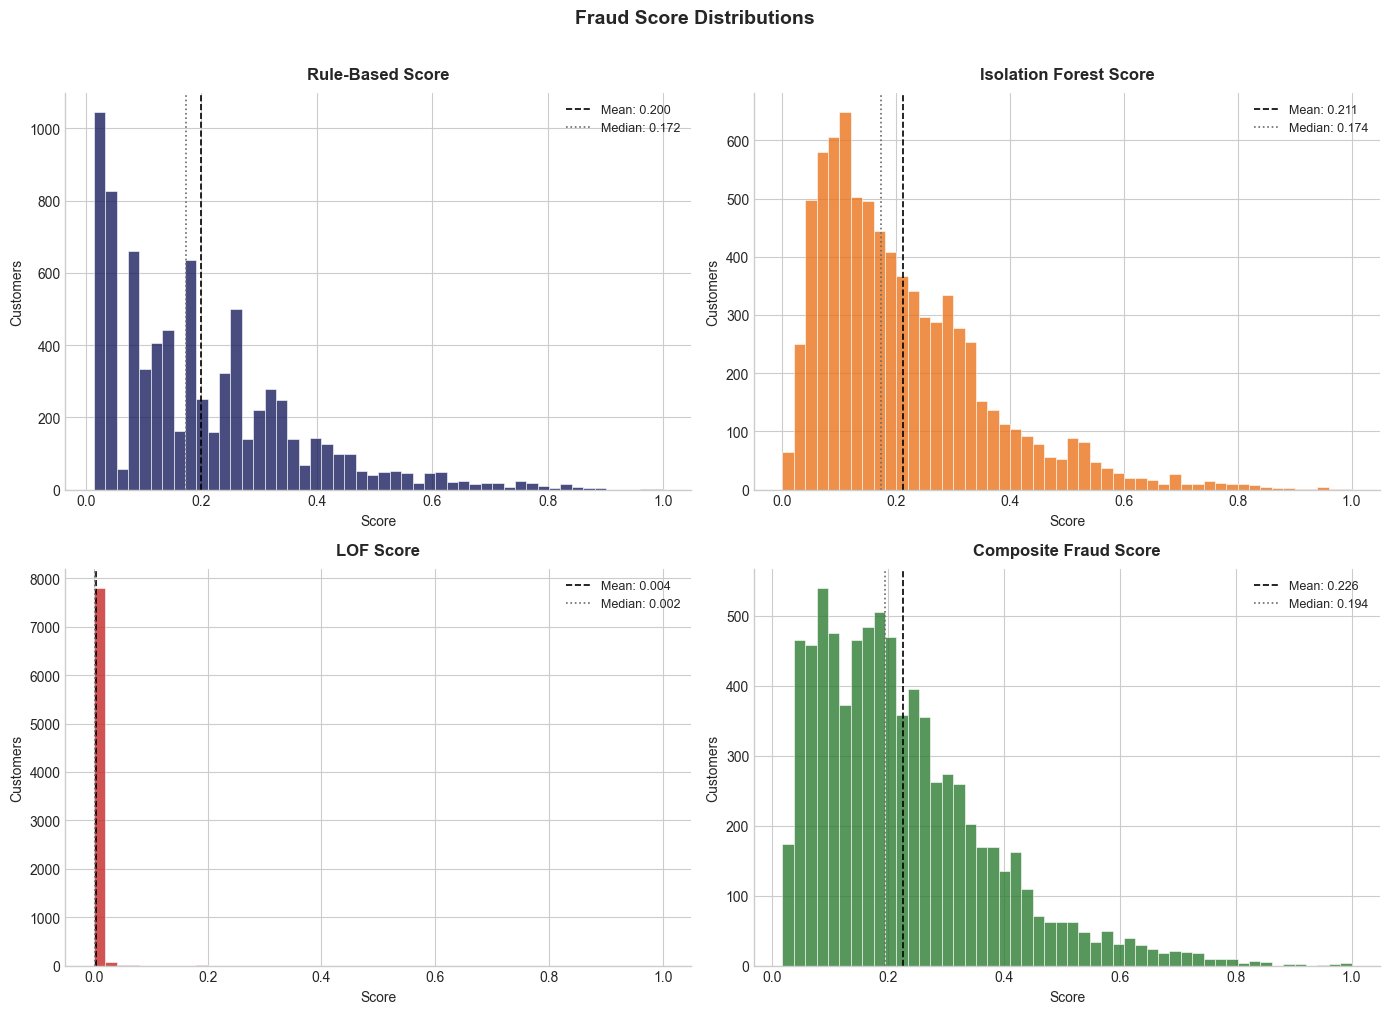

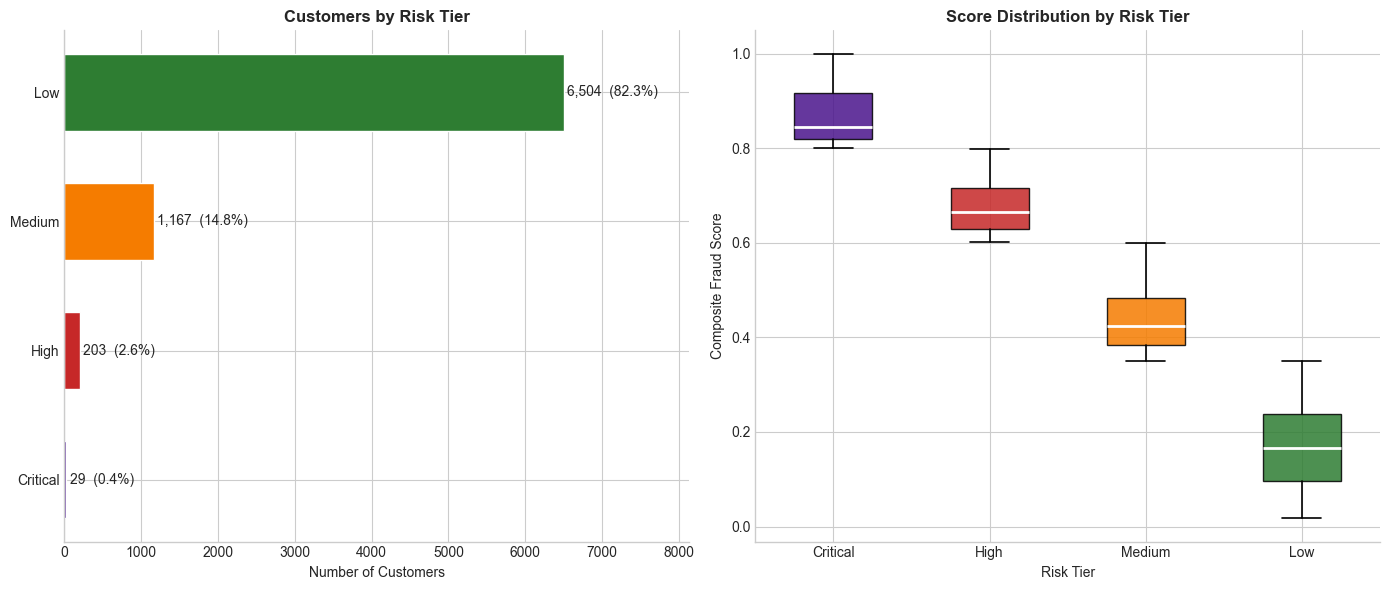

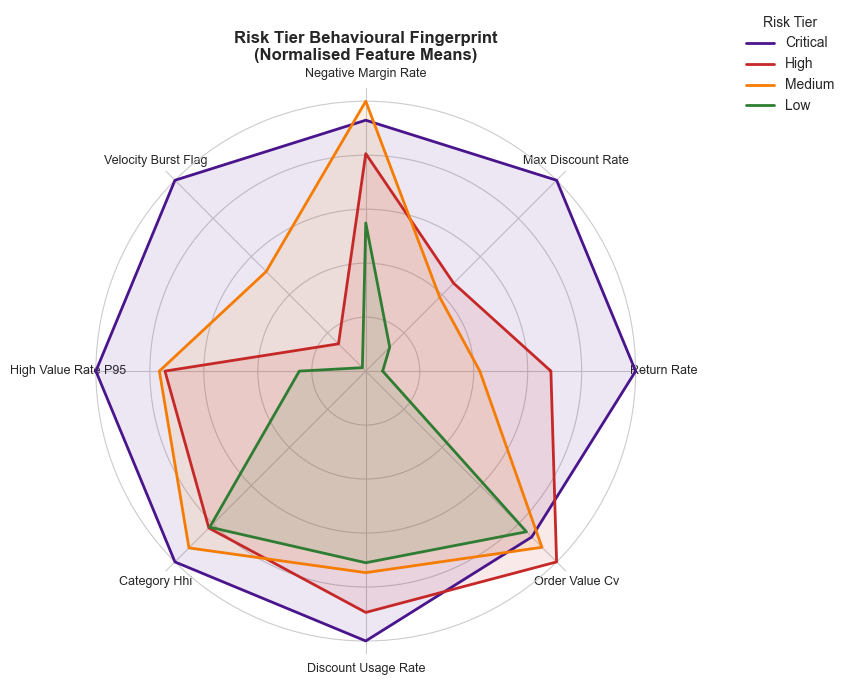

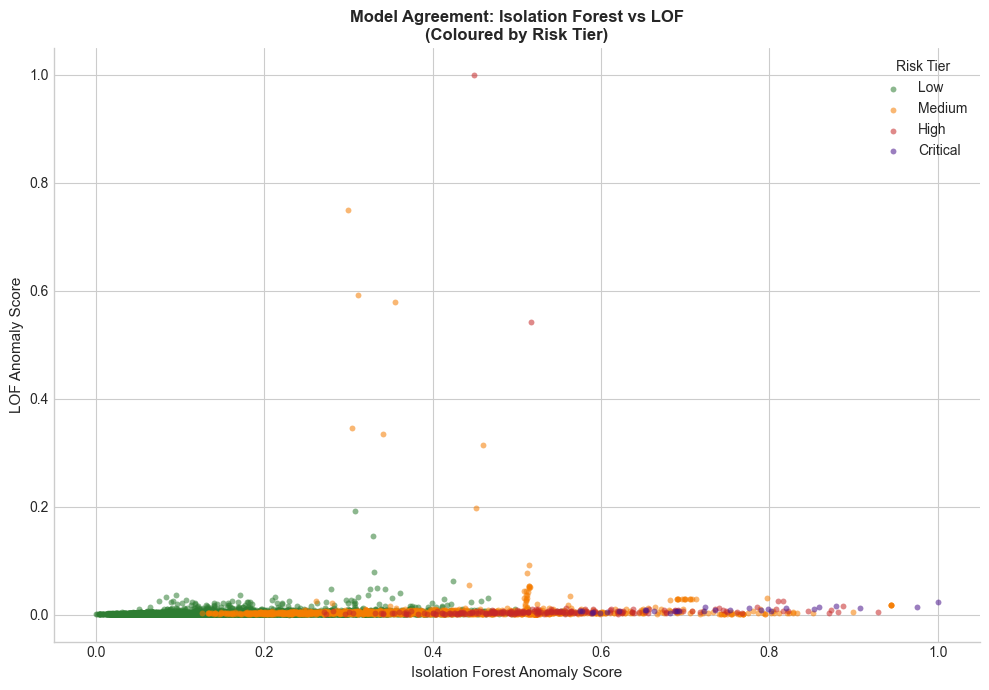

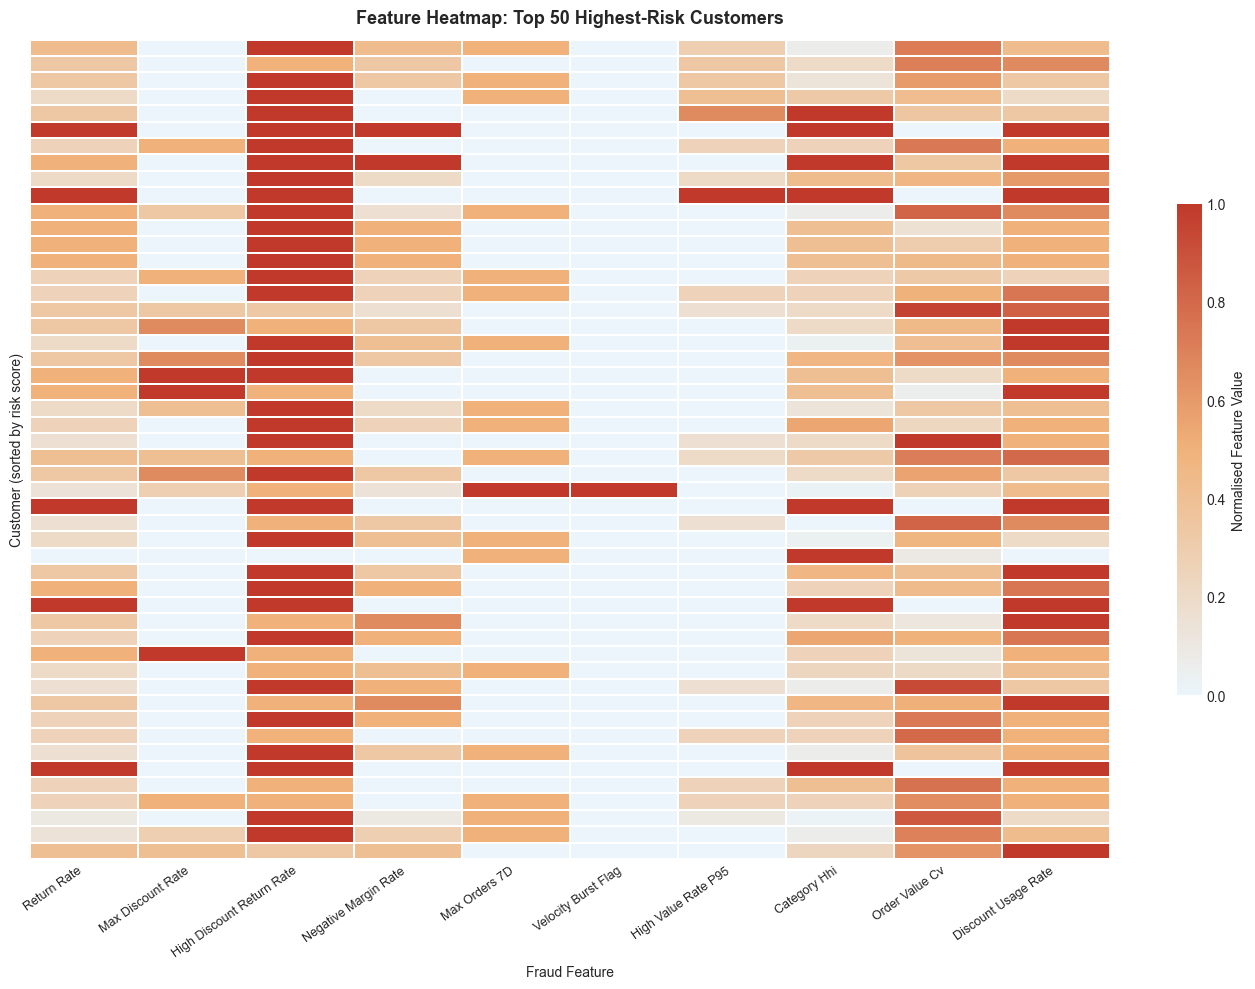

[WindowsPath('c:/Users/Rich Justine Gambe/Documents/AAA Projects/ecommerce-analytics-project/outputs/figures/notebook5_fig/top_risk_heatmap_B11970F1.png')]

In [10]:
from n5f_profiling import (
    plot_score_distributions, plot_risk_tier_breakdown,
    plot_feature_radar, plot_anomaly_scatter, plot_top_risk_heatmap,
)

SAVE  = True
SHOW  = True
SUBF  = 'notebook5_fig'

# Score distributions
plot_score_distributions(
    df_risk, config, save=SAVE, show=SHOW, subfolder=SUBF, run_id=run_id
)

# Risk tier breakdown
plot_risk_tier_breakdown(
    df_risk, config, save=SAVE, show=SHOW, subfolder=SUBF, run_id=run_id
)

# Feature radar (behavioural fingerprint by tier)
plot_feature_radar(
    df_risk, config, save=SAVE, show=SHOW, subfolder=SUBF, run_id=run_id
)

# IF vs LOF scatter
plot_anomaly_scatter(
    df_risk, config, save=SAVE, show=SHOW, subfolder=SUBF, run_id=run_id
)

# Top-50 heatmap
plot_top_risk_heatmap(
    df_risk, config, top_n=50, save=SAVE, show=SHOW, subfolder=SUBF, run_id=run_id
)

## 7. Typology Classification

Each high-risk customer is labelled with their primary fraud pattern based on activated feature thresholds (sourced from `config.yaml` for consistency with the scoring layer):

| Typology | Condition |
|---|---|
| **Return Abuser** | `return_rate` ≥ 20% |
| **Discount Exploiter** | `max_discount_rate` ≥ 80% **and** `avg_discount` > 15% |
| **Velocity Fraudster** | ≥ 3 orders in any 7-day window |
| **Margin Exploiter** | `negative_margin_rate` ≥ 50% |
| **High-Value Anomaly** | `high_value_rate_p99` > 20% |
| **Combined Attack** | 3+ typologies simultaneously active |
| **Unclassified** | No threshold met |

**Four findings that should drive next steps:**

1. **19.8% of High/Critical customers are Unclassified (46 of 232)** — 45 in the High tier, 1 in Critical. Return Abuse is the dominant pattern at 74.1% (172 of 232 High/Critical customers), confirming the return + high-discount co-occurrence identified in Section 4.1 as the primary risk signature. The Unclassified customers cleared the composite score threshold through multivariate patterns that no single rule threshold fires on individually.

2. **Margin Exploitation is now well-calibrated at the 50% threshold.** 873 customers (11.0% of the full base) meet the criterion; 786 (9.9%) carry it as their primary typology. Of those 786, the vast majority sit in Low tier and only 7 reach High — none reach Critical. This is a significant improvement over the previous 30% threshold, which inflated coverage to 22.5% and flagged large numbers of Low-tier customers exhibiting normal business-level margin variability. Monitor in future runs to ensure the tighter threshold is not under-capturing genuine exploitation.

3. **Critical tier = return fraud.** 27 of 29 Critical customers (93%) are Return Abusers; the remaining 2 are Velocity Anomaly and Unclassified. The tier is not a mixed-signal bucket — it is almost entirely one pattern, and any rule change to the return abuse logic will have an outsized effect on Critical-tier membership.

4. **No Combined Attack customers were identified** — the ≥3 typology co-occurrence threshold was never simultaneously met. The closest analogue is the 45 Unclassified High-tier customers, whose composite scores exceed 0.60 despite no single rule threshold firing. These warrant manual feature inspection to determine whether the Combined Attack threshold or individual rule thresholds need recalibration.


                         FRAUD TYPOLOGY CLASSIFICATION                          

Customers analysed:        7,903
High/Critical risk:        232

Typology                         All Customers  High-Risk Only
---------------------------------------------------------------
Return Abuse                            1,088            172
Discount Exploitation                      16              2
Velocity Anomaly                           27              2
Margin Exploitation                       873             30
High-Value Anomaly                        122             26
Combined Attack                             0              0

Primary Typology Distribution:
----------------------------------------
  Unclassified                  5,895 (74.6%)
  Return Abuse                  1,088 (13.8%)
  Margin Exploitation             786 (9.9%)
  High-Value Anomaly               91 (1.2%)
  Velocity Anomaly                 27 (0.3%)
  Discount Exploitation            16 (0.2%)

             

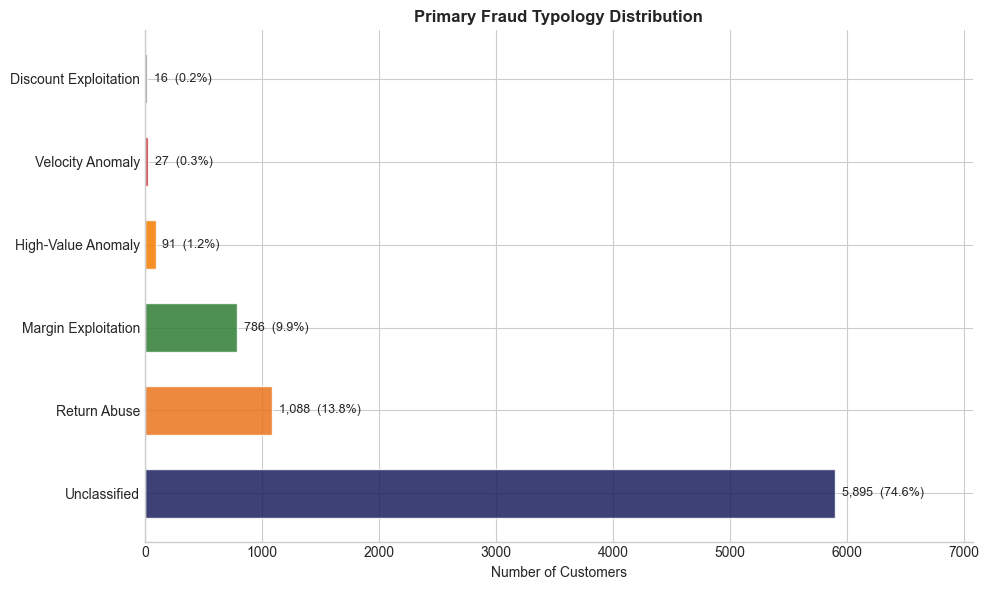

Figure saved: typology_distribution_B11970F1.png


In [11]:
from n5g_insights import classify_fraud_typology

df_typed = classify_fraud_typology(
    df=df_risk,
    config=config,
    run_id=run_id,
    verbose=True,
)

# Typology distribution by risk tier
typology_by_tier = pd.crosstab(
    df_typed['risk_tier'],
    df_typed['primary_typology'],
    margins=True,
)

print(f"\n{'='*80}")
print("TYPOLOGY BY RISK TIER".center(80))
print("=" * 80)
print()
print(typology_by_tier.to_string())
print("=" * 80)

# Visualise typology distribution
typology_counts = df_typed['primary_typology'].value_counts()
colors_list = config['visualization']['color_palette']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    typology_counts.index,
    typology_counts.values,
    color=[colors_list[i % len(colors_list)] for i in range(len(typology_counts))],
    alpha=0.85, edgecolor='white', height=0.6,
)
for bar, val in zip(bars, typology_counts.values):
    pct = val / len(df_typed) * 100
    ax.text(
        bar.get_width() + typology_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct:.1f}%)', va='center', ha='left', fontsize=9,
    )

ax.set_xlabel('Number of Customers', fontsize=10)
ax.set_title('Primary Fraud Typology Distribution', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, typology_counts.max() * 1.2)
plt.tight_layout()

fig_path = paths['figures'] / f'typology_distribution_{run_id}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Figure saved: {fig_path.name}")

## 8. Financial Exposure & Business Insights

Translates risk tier into dollar impact — but carefully. Each order is assigned to **exactly one** of three exposure buckets to prevent double-counting:

| Priority | Bucket | Logic |
|---|---|---|
| **P1** | Return exposure | All returned orders — regardless of discount or margin status |
| **P2** | Discount exposure | Kept orders with a discount applied |
| **P3** | Negative-margin exposure | Kept, undiscounted orders with negative margin |

Returned orders take precedence. If an order was both returned and discounted, it counts in P1 only. 339 overlapping orders were resolved this way, keeping the $96,822 total conservative and defensible.

In [12]:
from n5g_insights import estimate_financial_exposure, build_intervention_recommendations

exposure = estimate_financial_exposure(
    df=df_typed,
    transactions_df=df_tx,
    config=config,
    run_id=run_id,
    verbose=True,
)


                          FINANCIAL EXPOSURE ANALYSIS                           

High-Risk Customers:        232 (2.9%)
Revenue (High-Risk):         $  294,239.31 (5.0% of total)

Exposure Component                        High-Risk   All Customers  Bucket Priority
--------------------------------------------------------------------------------
Return Exposure                     $     87,512.03 $    388,756.00  Priority 1 — returned orders (total_amount)
Discount Exposure                   $      9,113.13 $    288,296.56  Priority 2 — kept orders with discount (price×qty×disc)
Negative Margin Losses              $        196.49 $      6,053.65  Priority 3 — kept, undiscounted, negative-margin orders
--------------------------------------------------------------------------------
Total Exposure (deduplicated)       $     96,821.65

  Deduplication report — orders resolved to one bucket only:
    Returned + discounted orders :  208  → assigned to Return bucket
    Returned + neg-margin

### 8.1 Intervention Recommendations

Prioritised action plan mapped to risk tier and fraud typology. Each recommendation carries a priority level and is annotated with customer count and estimated exposure to anchor the business case.

| Level | Meaning |
|---|---|
| **P0** | Immediate — act within 24 hours |
| **P1** | High — schedule this week |
| **P2** | Medium — monitor and trigger on next event |

**On Unclassified customers (19.8% of flagged — 46 customers, 45 High tier + 1 Critical):**
These customers cleared the composite score threshold — they are High
risk regardless of typology. The label means their risk is multi-signal
and doesn't map to any single named pattern, not that the risk is
questionable. When reviewing Unclassified rows in `fraud_risk_summary.csv`,
check whether multiple feature scores are simultaneously elevated rather
than looking for one dominant signal.

In [13]:
recommendations = build_intervention_recommendations(
    df=df_typed,
    exposure=exposure,
    config=config,
)

print(f"\n{'='*80}")
print("INTERVENTION RECOMMENDATIONS".center(80))
print("=" * 80)

for i, rec in enumerate(sorted(recommendations, key=lambda x: x['priority']), 1):
    print(f"\n[{rec['priority']}] {rec['tier']} Risk — {rec['action']}")
    print(f"-" * 70)
    print(f"{rec['rationale']}")

print(f"\n{'='*80}")



                          INTERVENTION RECOMMENDATIONS                          

[P0] Critical Risk — Immediate account review and manual verification
----------------------------------------------------------------------
These 232 customers account for $96,822 in estimated exposure. Automated flags should trigger human review within 24 hours.

[P1] High Risk — Implement purchase-to-return verification and return caps
----------------------------------------------------------------------
172 customers identified as return abusers. Introduce photo verification for high-value returns and cap returns to 2x per customer per quarter.

[P1] High Risk — Implement personalised discount eligibility rules
----------------------------------------------------------------------
2 customers systematically purchase only at maximum discount levels. Shift to loyalty-based discount allocation rather than blanket promotions.

[P1] High Risk — Add velocity checks to checkout with CAPTCHA escalation
----

### 8.2 Feature Correlation with Fraud Score

Spearman rank correlations between each feature and the composite score, ranked by effect size. Two thresholds guide interpretation:

- **|ρ| > 0.3** — strongly predictive; validates the engineering decision
- **|ρ| < 0.1** — marginal signal; candidate for removal or consolidation

15 of 16 features reach statistical significance (p < 0.05). `n_payment_methods` (ρ = 0.0115, p = 0.309) is no longer significant in this run and is a candidate for removal from the feature set. Statistical significance at n = 7,903 does not equal practical importance — effect size is what matters here.

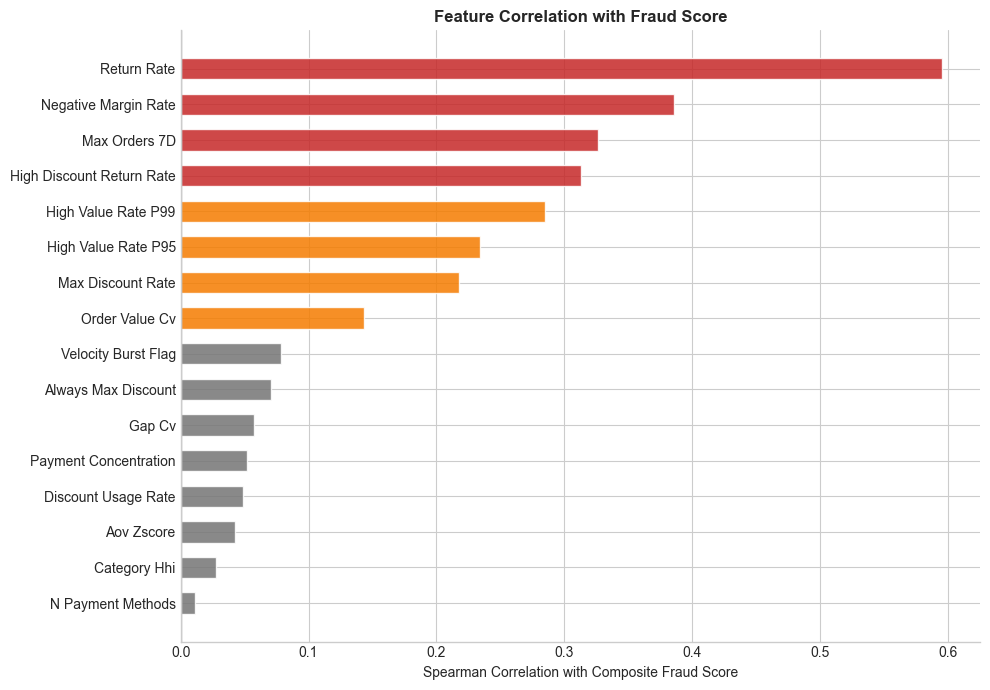

Figure saved: feature_correlation_B11970F1.png

Feature                               Spearman rho      p-value   Significance
------------------------------------------------------------------------------
return_rate                                 0.5952   0.0000e+00            ***
negative_margin_rate                        0.3858  8.8097e-279            ***
max_orders_7d                               0.3266  8.7078e-196            ***
high_discount_return_rate                   0.3133  1.7300e-179            ***
high_value_rate_p99                         0.2848  2.3753e-147            ***
high_value_rate_p95                         0.2341   8.4208e-99            ***
max_discount_rate                           0.2179   1.3389e-85            ***
order_value_cv                              0.1431   1.9787e-37            ***
velocity_burst_flag                         0.0785   2.7935e-12            ***
always_max_discount                         0.0707   3.1617e-10            ***
gap_

In [14]:
# Spearman correlations with composite fraud score
numeric_features = [f for f in available_model_features if f in df_typed.columns]

correlations = {}
for feat in numeric_features:
    rho, pval = stats.spearmanr(
        df_typed[feat].fillna(0),
        df_typed['composite_fraud_score'],
    )
    correlations[feat] = {'rho': rho, 'pval': pval}

corr_df = (
    pd.DataFrame(correlations).T
    .sort_values('rho', ascending=False)
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors_corr = [
    config['visualization']['colors']['danger']  if r >= 0.3 else
    config['visualization']['colors']['warning'] if r >= 0.1 else
    config['visualization']['colors']['neutral']
    for r in corr_df['rho']
]

ax.barh(
    corr_df.index[::-1].str.replace('_', ' ').str.title(),
    corr_df['rho'].values[::-1],
    color=colors_corr[::-1],
    alpha=0.85, edgecolor='white', height=0.6,
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman Correlation with Composite Fraud Score', fontsize=10)
ax.set_title('Feature Correlation with Fraud Score', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

fig_path = paths['figures'] / f'feature_correlation_{run_id}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Figure saved: {fig_path.name}")

# Print table
print(f"\n{'Feature':<35} {'Spearman rho':>14} {'p-value':>12} {'Significance':>14}")
print("-" * 78)
for feat, row in corr_df.iterrows():
    sig = '***' if row['pval'] < 0.001 else ('**' if row['pval'] < 0.01 else ('*' if row['pval'] < 0.05 else 'ns'))
    print(f"{feat:<35} {row['rho']:>14.4f} {row['pval']:>12.4e} {sig:>14}")
print("=" * 80)

### 8.3 Cross-Segment Risk Overlap

Joins NB03 customer segments and NB04 churn predictions onto NB05 fraud tiers to find customers carrying risk across multiple dimensions simultaneously.

**Reliability caveat:** NB03 segment membership is the stronger individual-level signal. NB04's churn model operates near chance (ROC-AUC = 0.498) — churn probabilities are weak contextual colour, not a second independent risk signal.

**Highest-priority compounded-risk cohort:**

| Cohort | Size | Why it matters |
|---|---|---|
| High-Value at Risk + High/Critical fraud | 42 customers | Revenue concentration meets behavioural risk — the highest combined business priority |

The previous run also tracked a high-churn + High/Critical fraud cohort (99 customers). With the 50% margin threshold, Combined Attack customers dropped to 0 and the H+C count rose to 232 — rerun the churn overlap query against the new `fraud_risk_profile.parquet` to get an updated double-risk count before quoting that figure downstream.


                  CROSS-NOTEBOOK SEGMENT x FRAUD RISK ANALYSIS                  


                            NB03 SEGMENT DATA LOADED                            

Source:    customer_segments.csv
Customers: 7,903

Segment                      Count    Share
---------------------------------------------
Needs Engagement             3,766    47.7%
Loyal Customers              2,215    28.0%
Lost Customers               1,442    18.2%
High-Value at Risk             480     6.1%

                         NB04 CHURN PREDICTIONS LOADED                          

Source:    customer_risk_segments.csv
Customers: 7,671

Risk level distribution:
  Medium      2,607 (34.0%)
  Low         2,532 (33.0%)
  High        2,532 (33.0%)

Churn probability — mean: 0.4997, median: 0.4979

Note: Logistic Regression ROC-AUC=0.498 (near-chance). Probability scores have limited
      discrimination power. Use as context, not ground truth.

                      SEGMENT x FRAUD RISK CROSS-ANALYSIS           

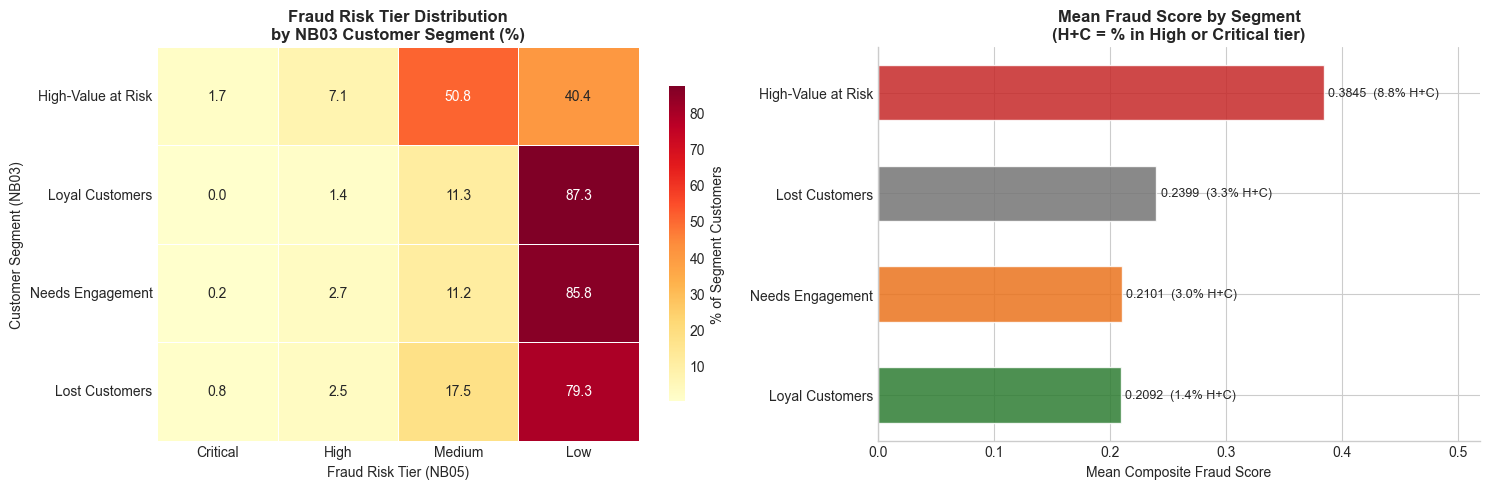


           FRAUD TYPOLOGY BY SEGMENT (High + Critical Customers Only)           

primary_typology    Discount Exploitation  High-Value Anomaly  Margin Exploitation  Return Abuse  Unclassified  Velocity Anomaly  All
segment_name                                                                                                                         
High-Value at Risk                      0                   3                    3            25            10                 1   42
Lost Customers                          2                   0                    1            44             0                 0   47
Loyal Customers                         0                   0                    1             6            23                 1   31
Needs Engagement                        0                   0                    2            97            13                 0  112
All                                     2                   3                    7           172            46   

In [15]:
from n5b_data_loader import load_segment_data, load_churn_predictions
from n5g_insights import build_segment_fraud_crosstab, plot_segment_fraud_heatmap

print_section_header("CROSS-NOTEBOOK SEGMENT x FRAUD RISK ANALYSIS")

# Load NB03 and NB04 outputs
nb3_segments  = load_segment_data(config, run_id=run_id, verbose=True)
nb4_churn     = load_churn_predictions(config, run_id=run_id, verbose=True)

# Build cross-tabulations
crosstab_results = build_segment_fraud_crosstab(
    df_fraud=df_typed,
    segments=nb3_segments,
    churn_preds=nb4_churn,
    config=config,
    run_id=run_id,
    verbose=True,
)

# Heatmap + bar chart
# Figure-saving controls
SAVE = True
SHOW = True
SUBF = "notebook5_fig"

plot_segment_fraud_heatmap(
    crosstab_results=crosstab_results,
    config=config,
    save=SAVE,
    show=SHOW,
    subfolder=SUBF,
    run_id=run_id,
)

# Typology breakdown by segment for high-risk customers only
merged_df = crosstab_results['merged']
high_risk_merged = merged_df[merged_df['risk_tier'].isin(['Critical', 'High'])]

if len(high_risk_merged) > 0:
    print(f"\n{'='*80}")
    print("FRAUD TYPOLOGY BY SEGMENT (High + Critical Customers Only)".center(80))
    print("=" * 80)

    typology_x_segment = pd.crosstab(
        high_risk_merged['segment_name'],
        high_risk_merged['primary_typology'],
        margins=True,
    )
    print()
    print(typology_x_segment.to_string())

    print(f"\nBusiness Interpretation:")
    print("-" * 60)

    # Segment-specific findings
    seg_order_interp = ['High-Value at Risk', 'Loyal Customers',
                        'Needs Engagement', 'Lost Customers']
    for seg in seg_order_interp:
        sub = high_risk_merged[high_risk_merged['segment_name'] == seg]
        if len(sub) == 0:
            continue
        top_typology = sub['primary_typology'].value_counts().index[0]
        top_count    = sub['primary_typology'].value_counts().iloc[0]
        avg_score    = sub['composite_fraud_score'].mean()
        print(
            f"  {seg:<25}: {len(sub):,} high-risk | "
            f"Primary typology: {top_typology} ({top_count:,}) | "
            f"Avg score: {avg_score:.4f}"
        )

    print("=" * 80)

logger.info("Cross-notebook analysis complete")

## 9. Data Quality Gate

Eight validation checks run against all model outputs before any file is written. Checks cover: score range integrity, risk tier and typology completeness, High/Critical rate bounds, anomaly detection coverage for both IF and LOF, and duplicate customer IDs.

**A single failure halts persistence.** Results in downstream notebooks are only trustworthy if this gate has passed.

In [16]:
print_section_header("DATA QUALITY VALIDATION")

nb5_thresholds = config.get('notebook5', {}).get('validation', {})

checks: list[dict] = []

def _check(name: str, passed: bool, detail: str, severity: str = 'error') -> None:
    status = 'PASS' if passed else ('WARN' if severity == 'warn' else 'FAIL')
    checks.append({'name': name, 'status': status, 'detail': detail})

# 1. Composite score in [0, 1]
_check(
    'Score range [0, 1]',
    df_typed['composite_fraud_score'].between(0, 1).all(),
    f"Min: {df_typed['composite_fraud_score'].min():.4f}, Max: {df_typed['composite_fraud_score'].max():.4f}",
)

# 2. All customers assigned a tier
null_tiers = df_typed['risk_tier'].isna().sum()
_check('All customers have risk tier', null_tiers == 0, f"{null_tiers} unassigned tiers")

# 3. Critical + High tier rate reasonable (< 15%)
max_hc_pct = nb5_thresholds.get('max_high_critical_pct', 15.0)
high_critical_pct = (df_typed['risk_tier'].isin(['Critical', 'High'])).mean() * 100
_check(
    f'High+Critical rate < {max_hc_pct:.0f}%',
    high_critical_pct < max_hc_pct,
    f"High+Critical: {high_critical_pct:.1f}%",
    severity='warn',
)

# 4. Anomaly detection coverage matches input
_check(
    'All customers have anomaly scores',
    df_typed[['iso_anomaly_score', 'lof_anomaly_score']].isna().sum().sum() == 0,
    f"Nulls: {df_typed[['iso_anomaly_score', 'lof_anomaly_score']].isna().sum().sum()}",
)

# 5. Both models flagged some anomalies
_check(
    'Isolation Forest detected anomalies',
    df_typed['iso_anomaly_flag'].sum() > 0,
    f"{df_typed['iso_anomaly_flag'].sum():,} flagged",
)
_check(
    'LOF detected anomalies',
    df_typed['lof_anomaly_flag'].sum() > 0,
    f"{df_typed['lof_anomaly_flag'].sum():,} flagged",
)

# 6. No duplicate customer IDs
dupes = df_typed['customer_id'].duplicated().sum()
_check('No duplicate customer IDs', dupes == 0, f"{dupes} duplicates")

# 7. Typology assigned to all customers
null_typology = df_typed['primary_typology'].isna().sum()
_check('All customers have typology', null_typology == 0, f"{null_typology} missing")

# Print results
all_passed = all(c['status'] in ('PASS', 'WARN') for c in checks)
n_pass = sum(1 for c in checks if c['status'] == 'PASS')
n_warn = sum(1 for c in checks if c['status'] == 'WARN')
n_fail = sum(1 for c in checks if c['status'] == 'FAIL')

print(f"\n{'Check':<45} {'Status':>6} {'Detail'}")
print("-" * 80)
for check in checks:
    print(f"  {check['name']:<43} [{check['status']:<4}]  {check['detail']}")

print(f"\nPassed: {n_pass} | Warnings: {n_warn} | Failed: {n_fail}")

if n_fail > 0:
    logger.warning("%d quality checks failed", n_fail)
    print("\nDATA QUALITY GATE: REVIEW REQUIRED — address failures before downstream use")
else:
    print("\nDATA QUALITY GATE: PASSED")

print("=" * 80)


                            DATA QUALITY VALIDATION                             


Check                                         Status Detail
--------------------------------------------------------------------------------
  Score range [0, 1]                          [PASS]  Min: 0.0173, Max: 1.0000
  All customers have risk tier                [PASS]  0 unassigned tiers
  High+Critical rate < 15%                    [PASS]  High+Critical: 2.9%
  All customers have anomaly scores           [PASS]  Nulls: 0
  Isolation Forest detected anomalies         [PASS]  395 flagged
  LOF detected anomalies                      [PASS]  396 flagged
  No duplicate customer IDs                   [PASS]  0 duplicates
  All customers have typology                 [PASS]  0 missing

Passed: 8 | Warnings: 0 | Failed: 0

DATA QUALITY GATE: PASSED


## 10. Persist Outputs

Two files written and schema-verified against the current run ID for lineage tracing:

| File | Size | Contents |
|---|---|---|
| `fraud_risk_profile.parquet` | 457 KB | 7,903 × 26 — full feature matrix, scores, tiers, typologies |
| `fraud_risk_summary.csv` | 17 KB | 232 High/Critical customers for analyst review |

Post-write column verification confirms schema integrity before the pipeline exits.

In [17]:
from n5h_data_saver import save_fraud_profile

saved_files = save_fraud_profile(
    df=df_typed,
    config=config,
    run_id=run_id,
    verbose=True,
)

logger.info("Outputs saved: %s", {k: str(v.name) for k, v in saved_files.items()})


                             PIPELINE OUTPUTS SAVED                             

  PARQUET   : fraud_risk_profile.parquet                       457.2 KB
  CSV       : fraud_risk_summary.csv                            16.5 KB

  Full profile:    7,903 customers, 26 features
  High/Critical:   232 customers flagged for review
19:23:49 | INFO     | __main__ | Outputs saved: {'parquet': 'fraud_risk_profile.parquet', 'csv': 'fraud_risk_summary.csv'}


## 11. Pipeline Complete

| Stage | Result |
|---|---|
| Input | 34,500 transactions · 7,903 customers |
| Features engineered | 16 model inputs from 38 candidates |
| Anomaly detection | IF: 395 flagged · LOF: 396 flagged · 82 in agreement |
| Risk tiers | 29 Critical · 203 High · 1,167 Medium · 6,504 Low |
| Financial exposure | $96,822 across 232 High/Critical customers |
| Outputs | `fraud_risk_profile.parquet` · `fraud_risk_summary.csv` |

Load `fraud_risk_profile.parquet` in downstream notebooks for reporting or further modelling.

In [18]:
# Final summary
tier_counts = df_typed['risk_tier'].value_counts()
critical_n  = tier_counts.get('Critical', 0)
high_n      = tier_counts.get('High', 0)

print("=" * 80)
print("NOTEBOOK 05 COMPLETE".center(80))
print("=" * 80)
print(f"\nRun ID:                {run_id}")
print(f"\nInputs used:")
print(f"  Transactions:        {len(df_tx):,} rows")
print(f"  Customers:           {fraud_features['customer_id'].nunique():,}")
print(f"\nFeature engineering:")
print(f"  Features built:      {len(available_model_features)}")
print(f"  Model input dim:     {len(available_model_features)}")
print(f"\nAnomaly detection:")
print(f"  Isolation Forest:    {metadata['iso_anomalies']:,} anomalies ({metadata['iso_anomalies']/metadata['n_customers']*100:.1f}%)")
print(f"  LOF:                 {metadata['lof_anomalies']:,} anomalies ({metadata['lof_anomalies']/metadata['n_customers']*100:.1f}%)")
print(f"  Both models agree:   {metadata['both_models_anomalies']:,} anomalies")
print(f"\nRisk tier distribution:")
for tier in ['Critical', 'High', 'Medium', 'Low']:
    n = tier_counts.get(tier, 0)
    pct = n / len(df_typed) * 100
    print(f"  {tier:<12}:       {n:,} customers ({pct:.1f}%)")
print(f"\nFinancial exposure:")
print(f"  Total estimated:     ${exposure['total_exposure_high_risk']:>12,.2f}")
print(f"  High-risk revenue:   ${exposure['revenue_high_risk']:>12,.2f} ({exposure['revenue_high_risk_pct']:.1f}% of total)")
print(f"\nOutputs saved:")
for ftype, path in saved_files.items():
    print(f"  {ftype.upper():<10}:       {path.name}")
print("=" * 80)

                              NOTEBOOK 05 COMPLETE                              

Run ID:                B11970F1

Inputs used:
  Transactions:        34,500 rows
  Customers:           7,903

Feature engineering:
  Features built:      16
  Model input dim:     16

Anomaly detection:
  Isolation Forest:    395 anomalies (5.0%)
  LOF:                 396 anomalies (5.0%)
  Both models agree:   82 anomalies

Risk tier distribution:
  Critical    :       29 customers (0.4%)
  High        :       203 customers (2.6%)
  Medium      :       1,167 customers (14.8%)
  Low         :       6,504 customers (82.3%)

Financial exposure:
  Total estimated:     $   96,821.65
  High-risk revenue:   $  294,239.31 (5.0% of total)

Outputs saved:
  PARQUET   :       fraud_risk_profile.parquet
  CSV       :       fraud_risk_summary.csv
